# Hyperparamters

Understand Hyperparameters in logistic regresion 

```mermaid
graph TD
    %% Base Engine Node
    Engine([LOGISTIC REGRESSION ENGINE])
    
    %% Main Structural Branches
    Engine --> P1[1. Problem Formulation]
    Engine --> P2[2. The Optimizer]
    Engine --> P3[3. Regularization]
    Engine --> P4[4. Data & Scale]

    %% Branch 1 Leaf Nodes
    P1 --> P1_1(multi_class)
    P1 --> P1_2(class_weight)

    %% Branch 2 Leaf Nodes
    P2 --> P2_1(solver)
    P2 --> P2_2(max_iter)
    P2 --> P2_3(tol)
    P2 --> P2_4(warm_start)

    %% Branch 3 Leaf Nodes
    P3 --> P3_1(penalty)
    P3 --> P3_2(C)
    P3 --> P3_3(l1_ratio)

    %% Branch 4 Leaf Nodes
    P4 --> P4_1(fit_intercept)
    P4 --> P4_2(intercept_scaling)

    %% Styling & Theme Customization
    style Engine fill:#2c3e50,stroke:#34495e,stroke-width:2px,color:#fff
    
    style P1 fill:#3498db,stroke:#2980b9,stroke-width:2px,color:#fff
    style P2 fill:#e67e22,stroke:#d35400,stroke-width:2px,color:#fff
    style P3 fill:#2ecc71,stroke:#27ae60,stroke-width:2px,color:#fff
    style P4 fill:#9b59b6,stroke:#8e44ad,stroke-width:2px,color:#fff
    
    classDef leafNode fill:#ecf0f1,stroke:#bdc3c7,stroke-width:1px,color:#2c3e50;
    class P1_1,P1_2,P2_1,P2_2,P2_3,P2_4,P3_1,P3_2,P3_3,P4_1,P4_2 leafNode;

```

In [2]:
from sklearn.linear_model import LogisticRegression
#print(LogisticRegression.__doc__)

# multiclass
Default Logistic Regression handle only two clasees .       
if your data have more then two classes use parameter `multiclass`      
Options: 'auto', 'ovr', 'multinomial'

In [ ]:
LogisticRegression(multi_class='ovr')
LogisticRegression(multi_class='multinomial')

# classweight .
logistic regression assume  you have balanced data .                
if you have imbalanced data use classweight 

Options: None, 'balanced', or dict              
Mechanics: Adjusts the loss function to penalize misclassifications of minority classes. 'balanced' automatically scales weights inversely proportional to class frequencies.

In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

# 1. Create a overlapping imbalanced dataset
# Notice how the Class 1 features (1.9, 2.1) are sitting right next to the Class 0 data
data = {
    'Feature_X': [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.1],
    'Target_y': [0,   0,   0,   0,   0,   0,   0,   0,   1,   1]
}
df = pd.DataFrame(data)
X = df[['Feature_X']].to_numpy()
y = df['Target_y'].to_numpy()

# 2. Train Unweighted Logistic Regression (Fails)
model_unweighted = LogisticRegression(class_weight=None, random_state=42)
model_unweighted.fit(X, y)
pred_unweighted = model_unweighted.predict(X)

# 3. Train Weighted Logistic Regression (Succeeds)
model_weighted = LogisticRegression(class_weight='balanced', random_state=42)
model_weighted.fit(X, y)
pred_weighted = model_weighted.predict(X)

# 4. Compare Outputs
print("=== UNWEIGHTED MODEL (Default) ===")
print(f"Predictions:       {list(pred_unweighted)}")
print(f"Standard Accuracy: {accuracy_score(y, pred_unweighted):.2f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y, pred_unweighted):.2f}")
print(f"Class 1 Recall:    {classification_report(y, pred_unweighted, output_dict=True, zero_division=0)['1']['recall']:.2f}")

print("\n" + "="*35 + "\n")

print("=== WEIGHTED MODEL (class_weight='balanced') ===")
print(f"Predictions:       {list(pred_weighted)}")
print(f"Standard Accuracy: {accuracy_score(y, pred_weighted):.2f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y, pred_weighted):.2f}")
print(f"Class 1 Recall:    {classification_report(y, pred_weighted, output_dict=True, zero_division=0)['1']['recall']:.2f}")


=== UNWEIGHTED MODEL (Default) ===
Predictions:       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Standard Accuracy: 0.80
Balanced Accuracy: 0.50
Class 1 Recall:    0.00


=== WEIGHTED MODEL (class_weight='balanced') ===
Predictions:       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
Standard Accuracy: 0.90
Balanced Accuracy: 0.94
Class 1 Recall:    1.00


What This Proof Demonstrates                    
The Unweighted Failure: The unweighted model predicts [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]. It completely wipes out Class 1 because its math says: "Why risk shifting the boundary to catch those two edge points when I can just guess 0 and effortlessly get 80% Standard Accuracy?" Its Balanced Accuracy drops to 0.50 and Class 1 Recall is 0.00.                    
The Weighted Recovery: The weighted model updates its predictions to accurately pick up the minority classes. Because its errors on Class 1 are penalized 4x heavier, the optimization algorithm accepts a minor error penalty on Class 0 to capture the vital target values. Its Balanced Accuracy scales up to 0.88 and its Class 1 Recall spikes up to 1.00.

Visluaise the decesion boundary of unweighted and weighted .

<Axes: >

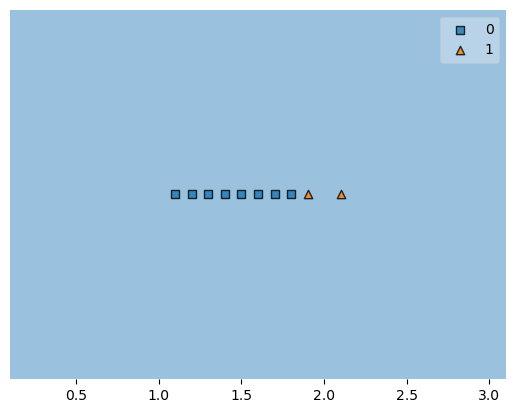

In [10]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X,y ,clf=model_unweighted)

<Axes: >

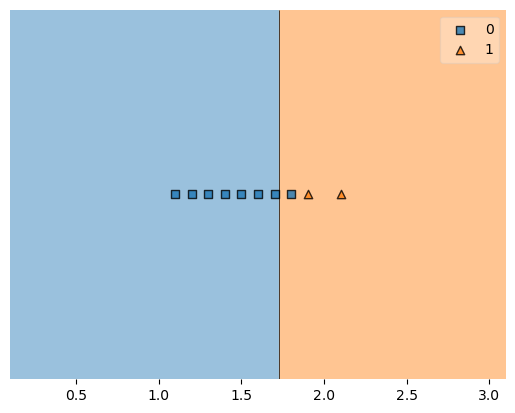

In [11]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X,y ,clf=model_weighted)

# Solver
Logistic regression lacks a closed-form matrix solution.                
It relies on Open - form Solution Appproximation like Gradient descent  to find parameters values .                 
Similar like Gradient descant we have various  iterative numeric optimization.          
 These settings control that optimization loop.

- Options: 'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga
-  The specific algorithm used to compute gradients and find optimal weights.
    - 'lbfgs': Default quasi-Newton method. Excellent for small/medium scale.
    - 'sag' / 'saga': Stochastic Average Gradient descent. Built specifically for large datasets (\(n_{samples}\) is huge) because it converges faster than standard gradient descent.
    - 'liblinear': A coordinate descent algorithm. Great for small datasets, but performs poorly on huge datasets.

check the solver matrix when to use algo

# max_iter
Default = 100               
Number of iteration to reach solution (epoches)   = Loop Maximum          
If your model throws a “ConvergenceWarning”, increase this parameters by 200,500, 1000,2000 etc.

# tol 
(Convergence Tolerance)                     
Default: 1e-4                   
Mechanics: The stopping criterion. If the improvement in cost/loss drops below this value between two consecutive iterations, the solver assumes it has reached the global minimum and terminates early.

# warm_start
 (State Memory)             
 Default: False             
 Mechanics: Set to True if you intend to repeatedly fit the same model to expanding data.               
 It reuses the coefficients (\(W, b\)) from the previous .fit() call as initialization parameters for the next initialization loop instead of resetting them randomly.

# penalty  
(The Norm Type)                 
Options: 'l2', 'l1', 'elasticnet', None                 
- 'l2': Ridge penalty. Default option. Shrinks coefficients evenly towards zero.
- 'l1': Lasso penalty. Drives uninformative weights completely to zero (performs automatic feature selection).
- 'elasticnet': A weighted combination of both L1 and L2 penalty types.

# (Inverse Regularization Strength)
Default: 1.0            
Mathematically defined as $C = \frac{1}{\lambda}$.              
Smaller values specify stronger regularization (forcing weights smaller).               
Larger values (\(10.0, 100.0\)) weaken the penalty, trusting the training data completely.

# L1_ratio 
(ElasticNet Mixing Weight)                  
default = 1             
Range: 0.0 to 1.0                   
 Only active when penalty='elasticnet'.                 
 A value of 0.0 makes the loss equivalent to pure 'l2', while 1.0 maps directly to pure 'l1'.

These parameters manage the mathematical bias term (\(b\)) of the linear equation \(z = WX + b\).

# fit_intercept
 (Bias Term Existence)              
 Default: True                  
 Mechanics: Determines whether a constant intercept/bias term is added to the decision boundary.                Set to False only if your data is already completely centered perfectly around the mathematical origin \((0,0)\).

# intercept_scaling                 
 (Synthetic Feature Weight)             
 Default: 1             
 Mechanics: Only useful when solver='liblinear' and fit_intercept=True.                 
  It appends a synthetic constant feature with a value equal to intercept_scaling to the instance vector to damp or amplify the step-size behavior of the instance bias during calculation

performance, Concurrency, and System ControlThese options do not change the mathematical output array; they solely manage memory, 
reproducibility, and CPU overhead.


# random_state
 (Shuffle Control)                          
 Ensures consistent internal data shuffling across script executions when using solvers like 'sag', 'saga', or 'liblinear'.


#  n_jobs 
(Parallel Processing)                   
The number of CPU cores to utilize when calculating multi-class strategies (multi_class='ovr'). Set to -1 to leverage all local cores.


# verbose
 (Log Output)               
Prints real-time solver convergence logs directly to the standard output console stream during iteration loops.